# Exploration des donnees DVF (Val-de-Marne, 2021-2025)

EDA et visualisations de controle a partir des fichiers DVF bruts.

Ce notebook genere 6 figures en inline :
1. Entonnoir de nettoyage
2. Comparaison des communes (prix median appartement)
3. Appartement vs Maison
4. Distribution (mediane vs moyenne)
5. Tendance temporelle
6. Volume de ventes par annee

In [1]:
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from aggregate import aggregate
from clean import PRIX_M2_MAX, PRIX_M2_MIN, TYPES_LOGEMENT, clean, load_raw

ANNEE_REF = 2024
MIN_VENTES = 20
TEAL, CORAL, BLUE = "#1D9E75", "#D85A30", "#185FA5"

plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})

In [2]:
def funnel_counts(raw):
    df = raw.copy()
    ventes = df[df["nature_mutation"] == "Vente"]
    batis = ventes[ventes["type_local"].notna()]
    nb = batis.groupby("id_mutation")["type_local"].transform("size")
    logement = batis[(nb == 1) & batis["type_local"].isin(TYPES_LOGEMENT)]
    surf = logement[logement["surface_reelle_bati"] > 0]
    pm2 = surf["valeur_fonciere"] / surf["surface_reelle_bati"]
    return {
        "Lignes brutes": len(df),
        "Lignes << Vente >>": len(ventes),
        "Ventes distinctes": ventes["id_mutation"].nunique(),
        "Mono-bien App/Maison": len(logement),
        "Surface batie > 0": len(surf),
        "Apres bornage EUR/m2": int(pm2.between(PRIX_M2_MIN, PRIX_M2_MAX).sum()),
    }

In [3]:
# Chargement et nettoyage (peut prendre quelques secondes)
pattern = "data/raw/dvf_94_*.csv"

raw = load_raw(pattern)
raw["annee"] = pd.to_datetime(raw["date_mutation"]).dt.year

ventes = clean(raw)
ind = aggregate(ventes)

print(f"Lignes brutes chargees : {len(raw):,}".replace(",", " "))
print(f"Ventes exploitables : {len(ventes):,}".replace(",", " "))
print(f"Lignes agregees : {len(ind):,}".replace(",", " "))

Lignes brutes chargees : 250 810
Ventes exploitables : 18 768
Lignes agregees : 460


---
## 1. Entonnoir de nettoyage
Chaque etape du pipeline de filtrage, des lignes brutes DVF jusqu'aux ventes exploitables.

  Lignes brutes                 250 810
  Lignes << Vente >>            210 231
  Ventes distinctes              87 671
  Mono-bien App/Maison           18 973
  Surface batie > 0              18 972
  Apres bornage EUR/m2           18 768


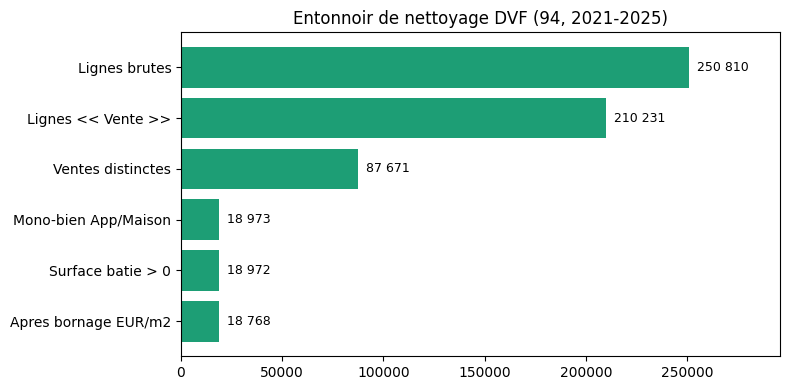

In [4]:
c = funnel_counts(raw)
for k, v in c.items():
    print(f"  {k:<28} {v:>8,}".replace(",", " "))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(c)[::-1], list(c.values())[::-1], color=TEAL)
for i, v in enumerate(list(c.values())[::-1]):
    ax.text(v, i, f"  {v:,}".replace(",", " "), va="center", fontsize=9)
ax.set_title("Entonnoir de nettoyage DVF (94, 2021-2025)")
ax.margins(x=0.18)
fig.tight_layout()
plt.show()

---
## 2. Comparaison des communes
Prix median EUR/m2 appartement sur l'annee de reference, pour les communes ayant au moins 20 ventes.

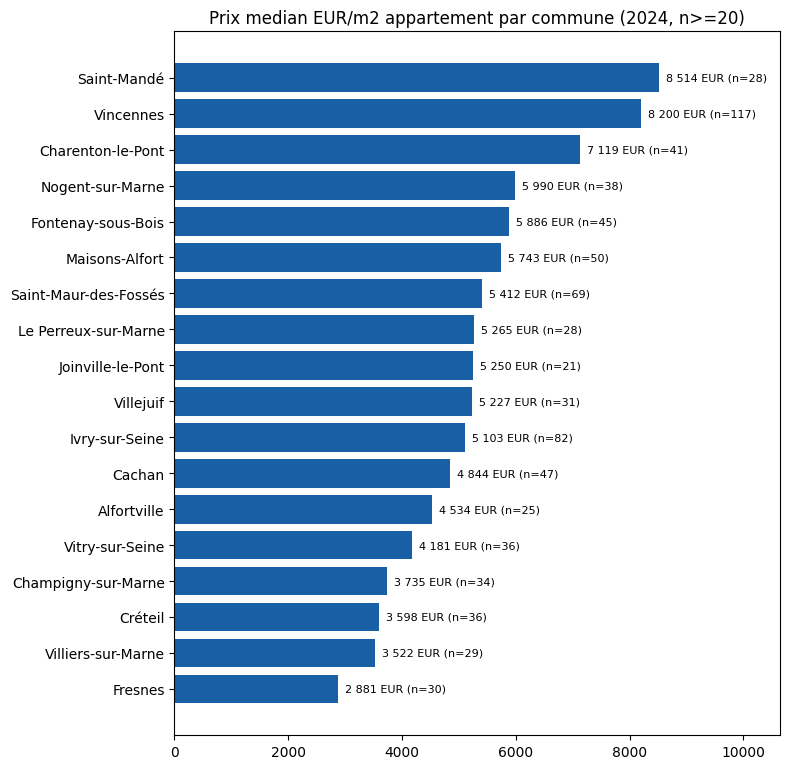

In [5]:
d = ind[(ind["type_local"] == "Appartement") & (ind["annee"] == ANNEE_REF)
        & (ind["nb_ventes"] >= MIN_VENTES)].sort_values("prix_m2_median")

fig, ax = plt.subplots(figsize=(8, 0.35 * len(d) + 1.5))
ax.barh(d["nom_commune"], d["prix_m2_median"], color=BLUE)
for y, (m, n) in enumerate(zip(d["prix_m2_median"], d["nb_ventes"])):
    ax.text(m, y, f"  {m:,.0f} EUR (n={n:.0f})".replace(",", " "), va="center", fontsize=8)
ax.set_title(f"Prix median EUR/m2 appartement par commune ({ANNEE_REF}, n>={MIN_VENTES})")
ax.margins(x=0.25)
fig.tight_layout()
plt.show()

---
## 3. Appartement vs Maison
Pourquoi il est indispensable de separer les deux types : la maison depasse souvent l'appartement au m2.

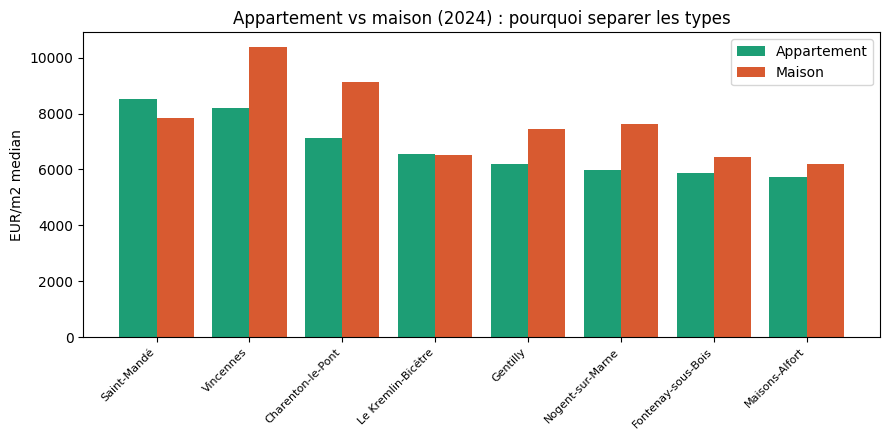

In [6]:
piv = (ind[ind["annee"] == ANNEE_REF]
       .pivot_table(index="nom_commune", columns="type_local", values="prix_m2_median")
       .dropna())
piv = piv.sort_values("Appartement", ascending=False).head(8)

x = range(len(piv))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([i - 0.2 for i in x], piv["Appartement"], 0.4, label="Appartement", color=TEAL)
ax.bar([i + 0.2 for i in x], piv["Maison"], 0.4, label="Maison", color=CORAL)
ax.set_xticks(list(x))
ax.set_xticklabels(piv.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("EUR/m2 median")
ax.legend()
ax.set_title(f"Appartement vs maison ({ANNEE_REF}) : pourquoi separer les types")
fig.tight_layout()
plt.show()

---
## 4. Distribution EUR/m2
La distribution des prix est asymetrique (moyenne > mediane), d'ou le choix de la mediane.

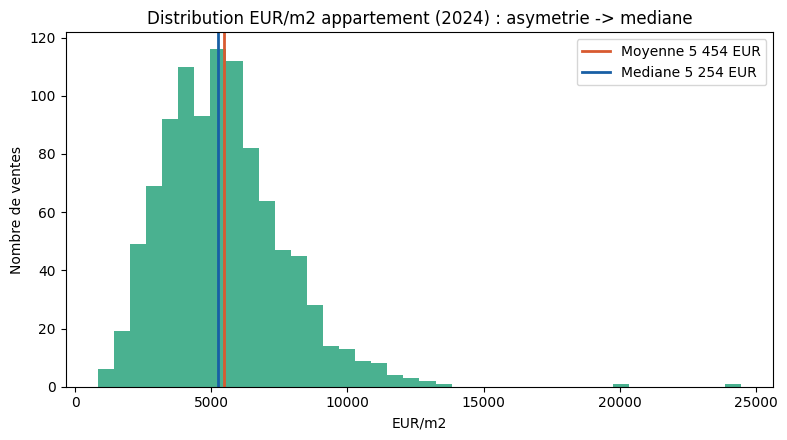

In [7]:
s = ventes[(ventes["type_local"] == "Appartement") & (ventes["annee"] == ANNEE_REF)]["prix_m2"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(s, bins=40, color=TEAL, alpha=0.8)
ax.axvline(s.mean(), color=CORAL, lw=2, label=f"Moyenne {s.mean():,.0f} EUR".replace(",", " "))
ax.axvline(s.median(), color=BLUE, lw=2, label=f"Mediane {s.median():,.0f} EUR".replace(",", " "))
ax.set_xlabel("EUR/m2")
ax.set_ylabel("Nombre de ventes")
ax.legend()
ax.set_title(f"Distribution EUR/m2 appartement ({ANNEE_REF}) : asymetrie -> mediane")
fig.tight_layout()
plt.show()

---
## 5. Tendance temporelle
Evolution du prix median EUR/m2 pour 3 communes representatives (la plus chere, la mediane, la plus abordable).

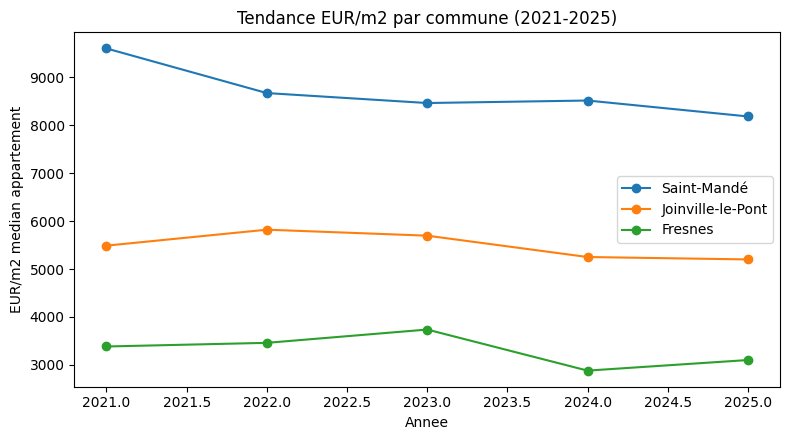

In [8]:
app = ventes[ventes["type_local"] == "Appartement"]
top = (app[app["annee"] == ANNEE_REF].groupby("nom_commune")["prix_m2"]
       .agg(["median", "size"]).query("size >= @MIN_VENTES").sort_values("median"))
choix = [top.index[-1], top.index[len(top) // 2], top.index[0]]

fig, ax = plt.subplots(figsize=(8, 4.5))
for nom in choix:
    serie = app[app["nom_commune"] == nom].groupby("annee")["prix_m2"].median()
    ax.plot(serie.index, serie.values, marker="o", label=nom)
ax.set_xlabel("Annee")
ax.set_ylabel("EUR/m2 median appartement")
ax.legend()
ax.set_title("Tendance EUR/m2 par commune (2021-2025)")
fig.tight_layout()
plt.show()

---
## 6. Volume de ventes
Nombre de ventes distinctes par annee. Le creux reel du marche est 2024 (pas 2025).

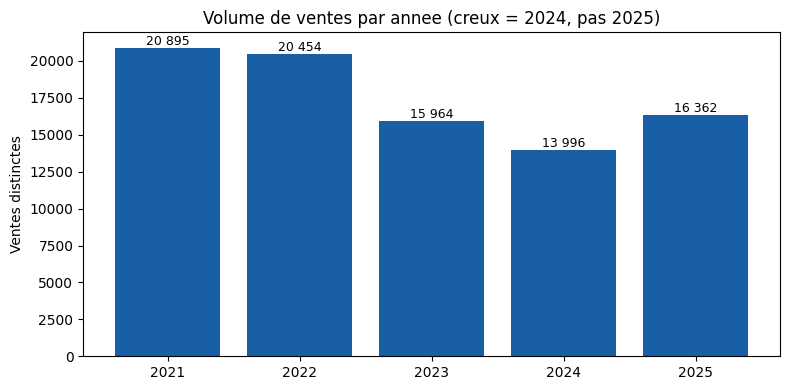

In [9]:
ventes_raw = raw[raw["nature_mutation"] == "Vente"].copy()
vol = ventes_raw.drop_duplicates("id_mutation").groupby("annee").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vol.index.astype(str), vol.values, color=BLUE)
for i, v in enumerate(vol.values):
    ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Ventes distinctes")
ax.set_title("Volume de ventes par annee (creux = 2024, pas 2025)")
fig.tight_layout()
plt.show()